In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Training models on [wug] and [wugs] embeddings

Below is a quick reminder of how we are teaching [wug] and [wugs] embeddings in the image and text conditions

### 1. Add [wug] and [wugs] tokens to embed layer and lm head (unembed layer), freeze all other model parameters.

We start by loading a Qwen model (with tied embed and head out embeddings, we'll see why in a second) and adding [wug] and [wugs] to the model token vocabulary.

### 2. Randomly initialize [wug] and [wugs] in noun cluster

We'll initialize [wug] and [wugs] in a cluster of both singular and plural nouns. This endows the embeddings with some distributional information that they are "object-y" without giving away whether [wug] or [wugs] is singular or plural. (remember orthography isn't accessible, so to the model these appear as tensors like [0.002,0.50323,0.52383]).

The plot below shows the initialization of wug/wugs in this "noun centroid"

In [5]:
import torch
import numpy as np
from minicons import scorer

MODEL = "Qwen/Qwen3-VL-2B-Instruct"
CACHE_DIR = "/mnt/dv/wid/projects3/Rogers-muri-human-ai/zstuddiford"
SEED = 0
NOUN_WORDS = ["dog", "dogs", "cat", "cats", "bird", "birds", "bear", "bears",
              "rat", "rats", "tree", "trees", "word", "words", "thing", "things"]

# --- seed everything ---
import random
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# --- load model ---
lm = scorer.VLMScorer(MODEL, device="cuda", torch_dtype=torch.bfloat16, cache_dir=CACHE_DIR)

# --- add the novel tokens (leading space, as in training) ---
added_tokens = [" [wug]", " [wugs]"]
vocab = lm.tokenizer.tokenizer.get_vocab()
to_add = [t for t in added_tokens if t not in vocab]
if to_add:
    lm.tokenizer.tokenizer.add_tokens(to_add)
    old_len = lm.model.resize_token_embeddings().weight.shape[0]
    lm.model.resize_token_embeddings(old_len + len(to_add))

emb = lm.model.model.language_model.embed_tokens
lm_head = lm.model.lm_head
tok = lm.tokenizer.tokenizer
assert emb.weight.data_ptr() == lm_head.weight.data_ptr(), "emb/lm_head not tied"

wug_id, wugs_id = [tok(t, add_special_tokens=False).input_ids[0] for t in added_tokens]

# --- init [wug]/[wugs] near the noun-cluster mean (noise scaled to mean S->P dist) ---
with torch.no_grad():
    target_norm = emb.weight.norm(dim=1).float().mean().item()

    def tid(w):
        ids = tok(" " + w, add_special_tokens=False).input_ids
        return ids[0] if len(ids) == 1 else None
    init_ids = [t for t in (tid(w) for w in NOUN_WORDS) if t is not None and t < emb.weight.shape[0]]
    assert len(init_ids) >= 4, f"only {len(init_ids)} single-token nouns"

    # noise scale = mean distance between consecutive (sing, plur) pairs
    dists = [(emb.weight[init_ids[i]] - emb.weight[init_ids[i+1]]).norm().item()
             for i in range(0, len(init_ids) - 1, 2)]
    noise_scale = float(np.mean(dists))

    mean_vec = emb.weight[init_ids].float().mean(dim=0)
    for token_id in (wug_id, wugs_id):
        noise = torch.randn_like(mean_vec)
        noise = noise / noise.norm() * noise_scale
        v = (mean_vec + noise)
        emb.weight.data[token_id] = (v / v.norm() * target_norm).to(emb.weight.dtype)

    print(f"noise_scale={noise_scale:.4f}  target_norm={target_norm:.4f}")
    print(f"[wug]  norm={emb.weight[wug_id].norm().item():.4f}")
    print(f"[wugs] norm={emb.weight[wugs_id].norm().item():.4f}")
    print(f"init separation={(emb.weight[wug_id]-emb.weight[wugs_id]).norm().item():.4f}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

noise_scale=1.1060  target_norm=1.4495
[wug]  norm=1.4531
[wugs] norm=1.4531
init separation=1.8047


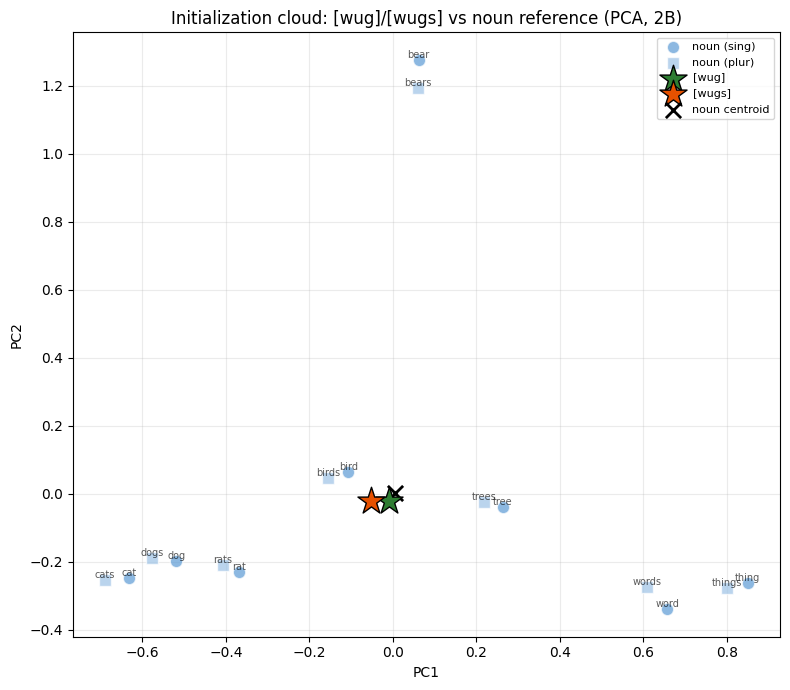

[wug]  dist to centroid: 1.2612
[wugs] dist to centroid: 1.3074
[wug]-[wugs] separation: 1.8039


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

with torch.no_grad():
    # noun-cluster vectors (the init_ids from the previous cell) + the two novel tokens
    noun_vecs = emb.weight[init_ids].float().cpu().numpy()
    wug_vec   = emb.weight[wug_id].float().cpu().numpy()
    wugs_vec  = emb.weight[wugs_id].float().cpu().numpy()

# labels for the noun points (init_ids was built from NOUN_WORDS, single-token only)
noun_labels = [tok.decode([i]).strip() for i in init_ids]

# fit PCA on nouns + novel tokens together so all share the same 2D space
all_vecs = np.vstack([noun_vecs, wug_vec[None], wugs_vec[None]])
coords = PCA(n_components=2, random_state=0).fit_transform(all_vecs)

noun_xy = coords[:len(noun_vecs)]
wug_xy  = coords[-2]
wugs_xy = coords[-1]

fig, ax = plt.subplots(figsize=(8, 7))

# noun cluster: color singular vs plural by alternating index (your list is paired)
sing_mask = [i for i in range(len(noun_labels)) if i % 2 == 0]
plur_mask = [i for i in range(len(noun_labels)) if i % 2 == 1]
ax.scatter(noun_xy[sing_mask, 0], noun_xy[sing_mask, 1], c="#5B9BD5", marker="o",
           s=80, alpha=0.7, edgecolors="white", label="noun (sing)", zorder=2)
ax.scatter(noun_xy[plur_mask, 0], noun_xy[plur_mask, 1], c="#9DC3E6", marker="s",
           s=80, alpha=0.7, edgecolors="white", label="noun (plur)", zorder=2)
for i, w in enumerate(noun_labels):
    ax.annotate(w, (noun_xy[i, 0], noun_xy[i, 1]), fontsize=7, alpha=0.65,
                ha="center", va="bottom")

# novel tokens as stars
ax.scatter(*wug_xy,  c="#2E7D32", marker="*", s=420, edgecolors="black",
           linewidths=1, label="[wug]", zorder=5)
ax.scatter(*wugs_xy, c="#E65100", marker="*", s=420, edgecolors="black",
           linewidths=1, label="[wugs]", zorder=5)

# noun centroid (where init was centered)
cen = noun_xy.mean(axis=0)
ax.scatter(*cen, c="k", marker="x", s=120, linewidths=2, label="noun centroid", zorder=4)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Initialization cloud: [wug]/[wugs] vs noun reference (PCA, 2B)")
ax.legend(fontsize=8, loc="best"); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

print(f"[wug]  dist to centroid: {np.linalg.norm(wug_vec  - noun_vecs.mean(0)):.4f}")
print(f"[wugs] dist to centroid: {np.linalg.norm(wugs_vec - noun_vecs.mean(0)):.4f}")
print(f"[wug]-[wugs] separation: {np.linalg.norm(wug_vec - wugs_vec):.4f}")

### 3. Zero-out updates to all tokens except wug and wugs. 

We'll freeze gradient updates and loss computations for every token except [wug] and [wugs]. After applying the mask, only these tokens will get updates.

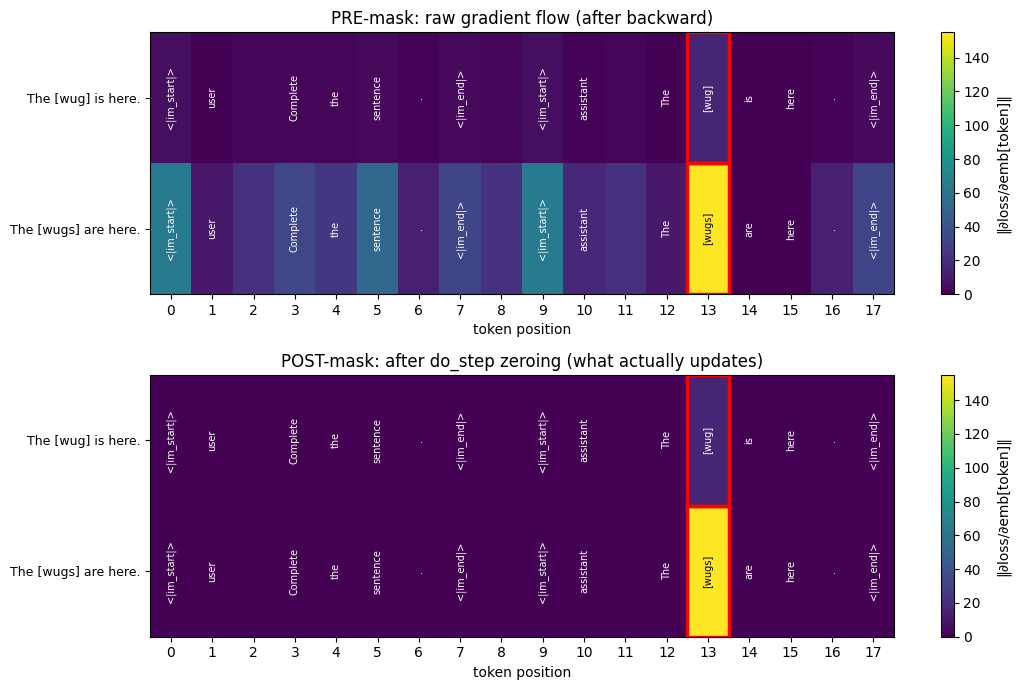

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.chat_templates import train_chat_template_noimage

example_sentences = [
    "The [wug] is here.",
    "The [wugs] are here.",
]

for p in lm.model.parameters():
    p.requires_grad = False
emb.weight.requires_grad = True
device = lm.model.device

def mask_to_novel_token(input_ids):
    labels = torch.full_like(input_ids, -100)
    for t in (wug_id, wugs_id):
        for pos in (input_ids == t).nonzero(as_tuple=True)[0]:
            labels[pos] = t
    return labels

records = []
for sent in example_sentences:
    text = train_chat_template_noimage(lm, sent)
    enc = lm.tokenizer(text=[text], return_tensors="pt", padding=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    input_ids = enc["input_ids"][0]
    labels = mask_to_novel_token(input_ids).unsqueeze(0).to(device)

    emb.weight.grad = None
    out = lm.model(**enc, labels=labels)
    out.loss.backward()

    tok_ids = input_ids.tolist()
    g = emb.weight.grad

    # PRE-mask: raw grad norm reaching each token's embedding row
    pre = [g[tid].norm().item() for tid in tok_ids]

    # POST-mask: replicate do_step — zero all rows except wug/wugs, then re-read
    gw  = g[wug_id].clone()
    gws = g[wugs_id].clone()
    g.zero_()
    g[wug_id]  = gw
    g[wugs_id] = gws
    post = [g[tid].norm().item() for tid in tok_ids]

    records.append({
        "sentence": sent,
        "tokens": [tok.decode([t]) for t in tok_ids],
        "supervised": (labels[0] != -100).int().cpu().tolist(),
        "pre": pre,
        "post": post,
    })

# build matrices (rows = examples, cols = token positions)
maxlen = max(len(r["tokens"]) for r in records)
def to_mat(key):
    m = np.full((len(records), maxlen), np.nan)
    for i, r in enumerate(records):
        m[i, :len(r[key])] = r[key]
    return m
pre_mat, post_mat = to_mat("pre"), to_mat("post")
vmax = np.nanmax(pre_mat)   # shared color scale so the two panels are comparable

fig, axes = plt.subplots(2, 1, figsize=(max(11, maxlen * 0.6), 5 + 1.0 * len(records)))
for ax, mat, title in [
    (axes[0], pre_mat,  "PRE-mask: raw gradient flow (after backward)"),
    (axes[1], post_mat, "POST-mask: after do_step zeroing (what actually updates)"),
]:
    im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
    thresh = vmax * 0.5
    for i, r in enumerate(records):
        for j, t in enumerate(r["tokens"]):
            cell = np.nan_to_num(mat[i, j])
            txt_color = "white" if cell < thresh else "black"
            ax.text(j, i, t.strip(), ha="center", va="center",
                    fontsize=7, color=txt_color, rotation=90)
            if r["supervised"][j]:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             fill=False, edgecolor="red", lw=2.5))
    ax.set_yticks(range(len(records)))
    ax.set_yticklabels([r["sentence"] for r in records], fontsize=9)
    ax.set_xticks(range(maxlen))
    ax.set_xlabel("token position")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="‖∂loss/∂emb[token]‖")

plt.tight_layout(); plt.show()

### 4. Train!

Now we are ready to train our embeddings. We'll define two conditions, one where embeddings are learned from visual input, with no syntactic information. In both cases, we'll train on just 15 examples (currently, we repeatedly sample from just 5 singular/plural images). 

We also found that we cannot have exact duplicate pairs for wug/wugs: i.e

The wug over there
The wugs over there

Because the gradient updates compete with eachother (and are often perfectly complementary). There must be small differences for learning to take place, i.e

The wug over there
The wugs over here

Small but important!


### Image condition:

10 images in ../../data/embeddings/train/im/creature_1


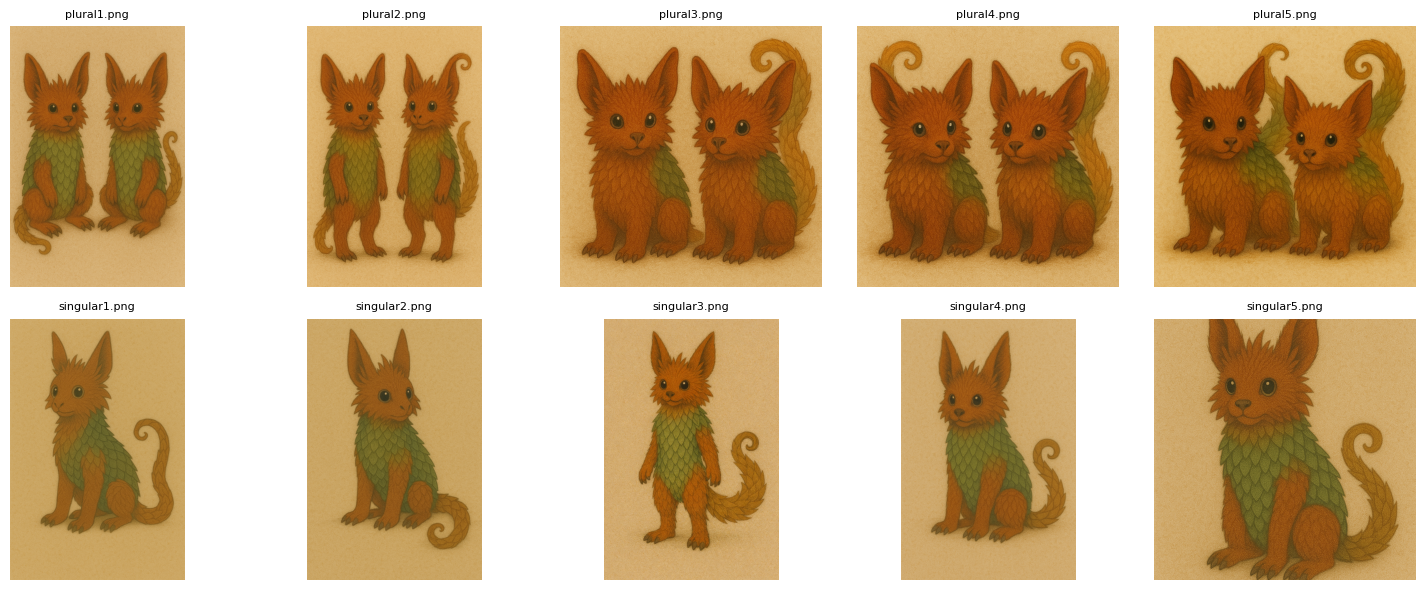


image_train_1.csv — 30 rows, columns: ['type', 'sentence']


,type,sentence
0,singular,[wug]?
1,singular,"[wug], there."
2,singular,The [wug] from over there.
3,singular,[wug] over there.
4,singular,[wug] near the fence.
5,singular,[wug] around the chair.
6,singular,Do you see the [wug] near the fence?
7,singular,I walked past the [wug] along the path.
8,singular,I found the [wug] under the lamp.
9,singular,I stood beside the [wug] by the gate.


In [1]:
import os, glob
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

IMG_DIR  = "../../data/embeddings/train/im/creature_1"
TRAIN_CSV = "../../data/embeddings/train/text/image_train_1.csv"

# --- images ---
img_paths = sorted(
    glob.glob(os.path.join(IMG_DIR, "*"))
)
img_paths = [p for p in img_paths
             if p.lower().endswith((".png", ".jpg", ".jpeg", ".webp", ".gif", ".bmp"))]

print(f"{len(img_paths)} images in {IMG_DIR}")
if img_paths:
    ncols = min(5, len(img_paths))
    nrows = (len(img_paths) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]
    for ax, p in zip(axes, img_paths):
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis("off")
    for ax in axes[len(img_paths):]:   # hide any empty cells
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("  (no image files found — check the path)")

# --- train CSV ---
df = pd.read_csv(TRAIN_CSV)
print(f"\nimage_train_1.csv — {df.shape[0]} rows, columns: {list(df.columns)}")
display(df)

### Syntax condition

In [2]:
import pandas as pd

SYNTAX_CSV = "../../data/embeddings/train/text/syntax_train_1.csv"

df_syntax = pd.read_csv(SYNTAX_CSV)
print(f"syntax_train_1.csv — {df_syntax.shape[0]} rows, columns: {list(df_syntax.columns)}")
display(df_syntax)

syntax_train_1.csv — 30 rows, columns: ['type', 'sentence']


,type,sentence
0,singular,One [wug].
1,singular,A single [wug].
2,singular,There sits a [wug].
3,singular,I spotted a [wug].
4,singular,That is definitely a [wug].
5,singular,The [wug] shook its tail before running away.
6,singular,Beneath the stairs crouched a frightened [wug].
7,singular,Does the [wug] always come back at night?
8,singular,One [wug] carries a small leaf in its mouth.
9,singular,The [wug] near the window makes a soft sound.


# Hyperparameter selection for embeddings

As a start, let's sweep across many possible learning rates based on a range which seems to be promising based on preliminary results (approx 10^-4...10^-1). For each LR, we'll run across five random seeds to get an estimate of our consistency. We'll also evaluate on many different sentences/constructions not seen by the model to ensure we are actually generalizing.

In [4]:
import pandas as pd

EVAL_CSV = "../../data/embeddings/eval/singular_plural_eval.csv"

df_eval = pd.read_csv(EVAL_CSV)
print(f"singular_plural_eval.csv — {df_eval.shape[0]} rows, columns: {list(df_eval.columns)}")
display(df_eval)

singular_plural_eval.csv — 238 rows, columns: ['good_sentence', 'bad_sentence']


,good_sentence,bad_sentence
0,The [wug] jumps across the rock while another ...,The [wugs] jumps across the rock while another...
1,Two [wugs] climb over the fence together.,Two [wug] climb over the fence together.
2,I noticed the [wug] was hiding behind the tree.,I noticed the [wugs] was hiding behind the tree.
3,Several [wugs] gather near the edge of the pond.,Several [wug] gathers near the edge of the pond.
4,A single [wug] was resting on the branch when ...,A single [wugs] were resting on the branch whe...
...,...,...
233,Into the burrow crawl several [wugs].,Into the burrow crawl several [wug].
234,Beyond the wall waits a [wug].,Beyond the wall waits a [wugs].
235,Beyond the wall wait the [wugs].,Beyond the wall wait the [wug].
236,It turned out to be a [wug].,It turned out to be a [wugs].


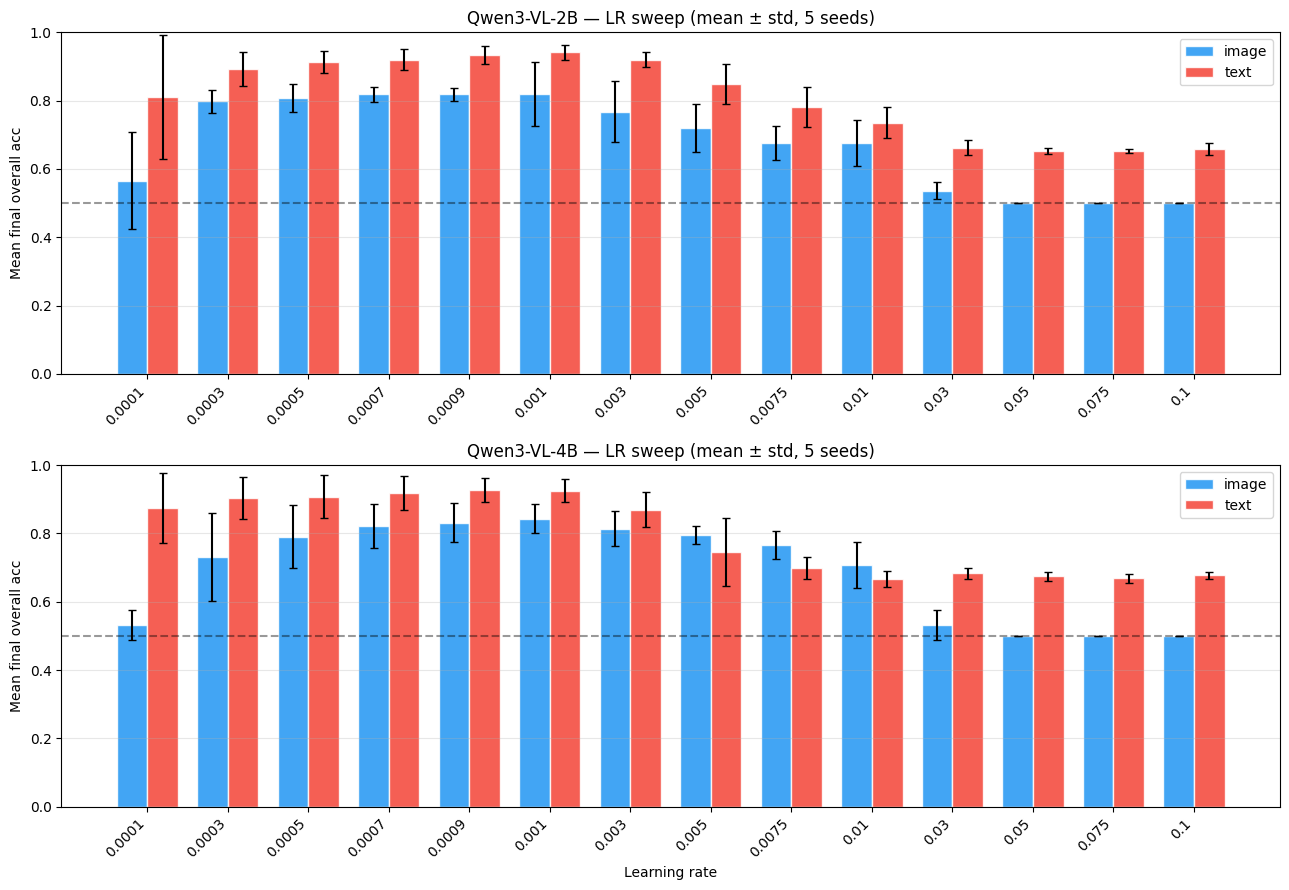

In [3]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RESULTS_ROOT = "../.."   # adjust if notebook is deeper (e.g. "../..")
RES = os.path.join(RESULTS_ROOT, "results")

def collect_sweep(d):
    rows = []
    for p in glob.glob(os.path.join(d, "**", "run_summary.csv"), recursive=True):
        r = pd.read_csv(p).iloc[0]
        rows.append({"lr": float(r["lr"]), "seed": int(r["seed"]),
                     "overall": float(r["final_overall"])})
    df = pd.DataFrame(rows)
    if df.empty: print(f"WARNING: empty {d}")
    return df

def agg_sweep(df):
    g = df.groupby("lr")["overall"].agg(mean="mean", std="std", n="count").reset_index().sort_values("lr")
    g["std"] = g["std"].fillna(0.0)
    return g

sweep_dirs = {
    "2B": {"image": "lr_sweep_results_Qwen3-VL-2B-Instruct_image_5seeds",
           "text":  "lr_sweep_results_Qwen3-VL-2B-Instruct_text_5seeds"},
    "4B": {"image": "lr_sweep_results_Qwen3-VL-4B-Instruct_image_5seeds",
           "text":  "lr_sweep_results_Qwen3-VL-4B-Instruct_text_5seeds"},
}

sweep = {m: {c: agg_sweep(collect_sweep(os.path.join(RES, dn))) for c, dn in conds.items()}
         for m, conds in sweep_dirs.items()}

colors = {"image": "#2196F3", "text": "#F44336"}
models = ["2B", "4B"]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)
for ax, m in zip(axes, models):
    a = sweep[m]
    all_lrs = sorted(set().union(*[set(a[c]["lr"]) for c in a if not a[c].empty]))
    x = np.arange(len(all_lrs)); width = 0.38
    for i, c in enumerate(["image", "text"]):
        if a[c].empty: continue
        idx = a[c].set_index("lr")
        means = [idx["mean"].get(lr, np.nan) for lr in all_lrs]
        errs  = [idx["std"].get(lr, np.nan)  for lr in all_lrs]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=errs, capsize=3,
               label=c, color=colors[c], alpha=0.85, edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels([f"{lr:g}" for lr in all_lrs], rotation=45, ha="right")
    ax.set_ylim(0, 1); ax.axhline(0.5, color="k", ls="--", alpha=0.4)
    ax.set_ylabel("Mean final overall acc")
    ax.set_title(f"Qwen3-VL-{m} — LR sweep (mean ± std, 5 seeds)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
axes[-1].set_xlabel("Learning rate")
plt.tight_layout(); plt.show()

It seems like 0.001 works well for both the 2B and 4B model! Can we be confident that models will learn [wug] and [wugs] in these conditions with some degree of consistency? Let's do 50 training runs for each embedding condition/model at LR=0.001 with different randomly initialized seeds. This will tell us whether the learning is just some artifact of where the embeddings were initialized.

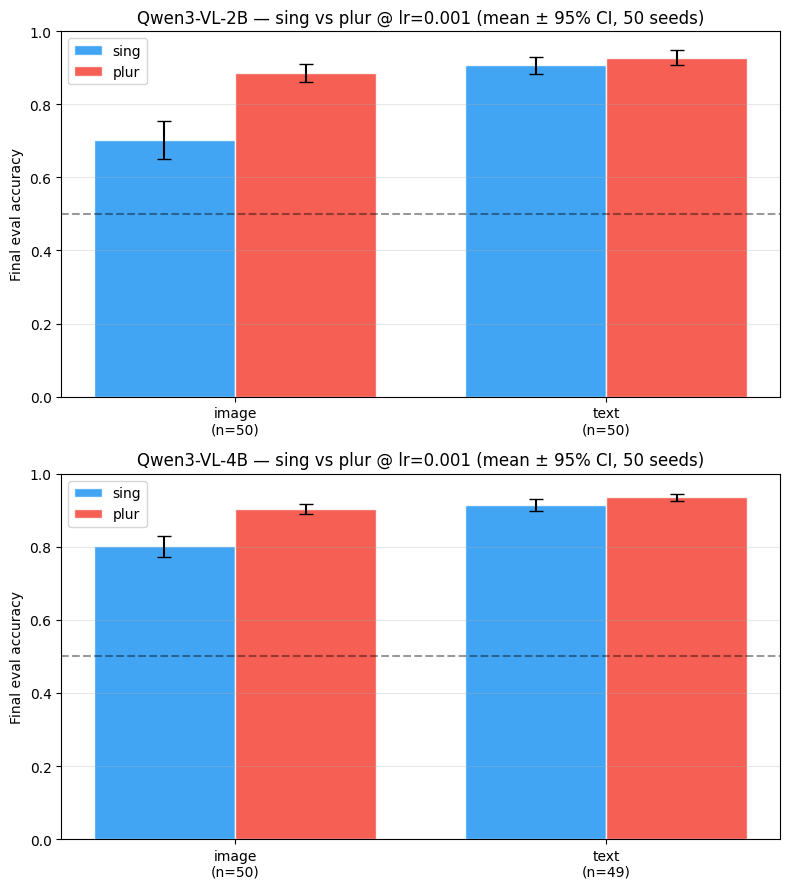

In [4]:
def collect_ci(d):
    rows = []
    for p in glob.glob(os.path.join(d, "**", "run_summary.csv"), recursive=True):
        r = pd.read_csv(p).iloc[0]
        rows.append({"seed": int(r["seed"]),
                     "sing": float(r["final_sing"]), "plur": float(r["final_plur"])})
    df = pd.DataFrame(rows)
    if df.empty: print(f"WARNING: empty {d}")
    return df

def mean_ci95(x):
    x = np.asarray(x, float); n = len(x); m = x.mean()
    if n < 2: return m, 0.0
    se = x.std(ddof=1) / np.sqrt(n)
    return m, se * stats.t.ppf(0.975, n - 1)

ci_dirs = {
    "2B": {"image": "lr_ci_results_Qwen3-VL-2B-Instruct_image_lr0p001_50seeds",
           "text":  "lr_ci_results_Qwen3-VL-2B-Instruct_text_lr0p001_50seeds"},
    "4B": {"image": "lr_ci_results_Qwen3-VL-4B-Instruct_image_lr0p001_50seeds",
           "text":  "lr_ci_results_Qwen3-VL-4B-Instruct_text_lr0p001_50seeds"},
}

ci = {}
for m, conds in ci_dirs.items():
    ci[m] = {}
    for c, dn in conds.items():
        df = collect_ci(os.path.join(RES, dn))
        if not df.empty:
            ci[m][c] = {"sing": mean_ci95(df["sing"]), "plur": mean_ci95(df["plur"]), "n": len(df)}

gcolors = {"sing": "#2196F3", "plur": "#F44336"}

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
for ax, m in zip(axes, models):
    conds = list(ci[m].keys())
    x = np.arange(len(conds)); width = 0.38
    for i, g in enumerate(["sing", "plur"]):
        means = [ci[m][c][g][0] for c in conds]
        errs  = [ci[m][c][g][1] for c in conds]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=errs, capsize=5,
               label=g, color=gcolors[g], alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n(n={ci[m][c]['n']})" for c in conds])
    ax.set_ylim(0, 1); ax.axhline(0.5, color="k", ls="--", alpha=0.4)
    ax.set_ylabel("Final eval accuracy")
    ax.set_title(f"Qwen3-VL-{m} — sing vs plur @ lr=0.001 (mean ± 95% CI, 50 seeds)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

Pretty good! slightly better generalization in the larger parameter model, which makes sense. The default behavior for all models seems to be guessing the plural embedding 100% of the time, which is why we see discrepancies in eval accuracy for [wug] and [wugs].